In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="darkgrid")
plt.style.use('seaborn-v0_8-darkgrid')

# Display all columns
pd.set_option('display.max_columns', None)

In [ ]:
# Load dataset (adjust file path as needed)
df = pd.read_csv('retail_sales_dataset.csv')

# Display basic info
df.info()

df.head()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create derived columns for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Handle missing values if necessary
# For critical columns like CustomerID, drop rows
df = df.dropna(subset=['Customer ID'])

# For other columns, consider imputation
# df.fillna({'Discount': 0}, inplace=True)

In [ ]:
# Create a Sales column using the correct column names
df['Sales'] = df['Quantity'] * df['Price per Unit']

In [ ]:
# 1. Main summary table for numerical columns
display(df.describe())

# 2. Extract additional statistics cleanly into a DataFrame
numerical_cols = df.select_dtypes(include=[np.number]).columns
extra_stats = pd.DataFrame(index=['Median', 'Mode', 'Std Dev'], columns=numerical_cols)

for col in numerical_cols:
    extra_stats.loc['Median', col] = df[col].median()
    extra_stats.loc['Mode', col] = df[col].mode().values[0] if not df[col].mode().empty else None
    extra_stats.loc['Std Dev', col] = round(df[col].std(), 2)

# Display the extra stats table
display(extra_stats)

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year,Month,Quarter,Sales
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2023.002000,6.549000,2.525000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000,1.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000,4.000000,2.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000,6.000000,2.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000,10.000000,4.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000,12.000000,4.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699,3.452755,1.119208,559.997632


,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Year,Month,Quarter,Sales
Median,500.5,42.0,3.0,50.0,135.0,2023.0,6.0,2.0,135.0
Mode,1,43,4,50,50,2023,5,2,50
Std Dev,288.82,13.68,1.13,189.68,560.0,0.04,3.45,1.12,560.0


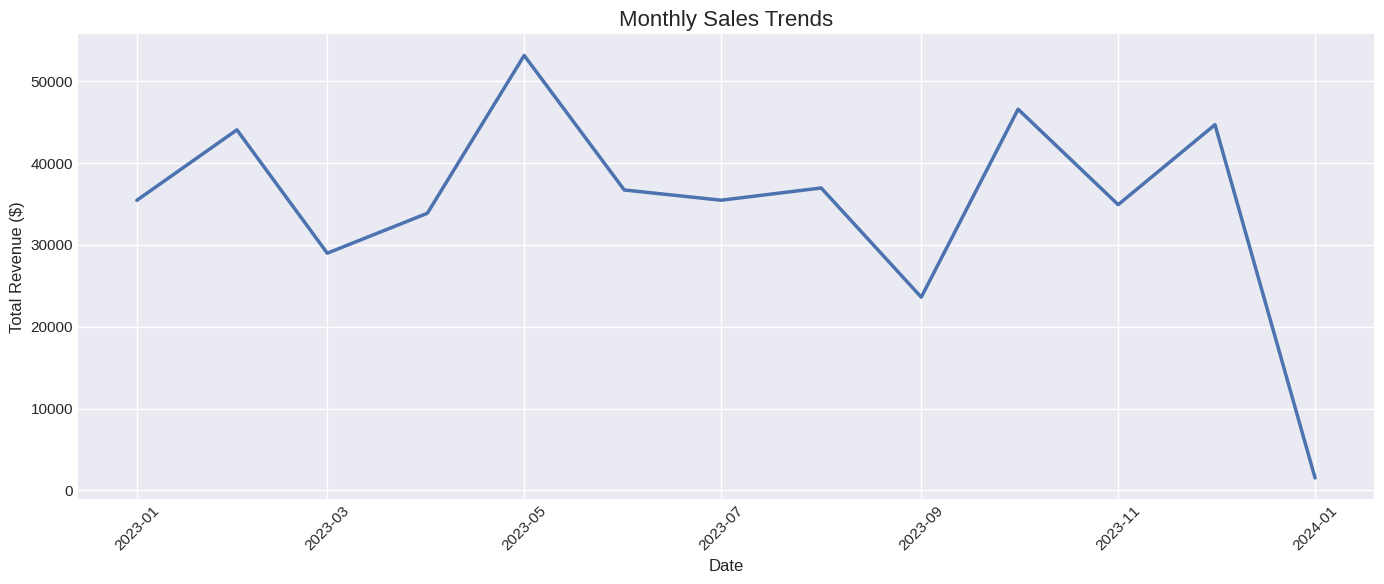

In [ ]:
# Group by month and sum sales (Fixed column name from 'TotalPrice' to 'Sales')
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', linewidth=2.5)
plt.title('Monthly Sales Trends', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

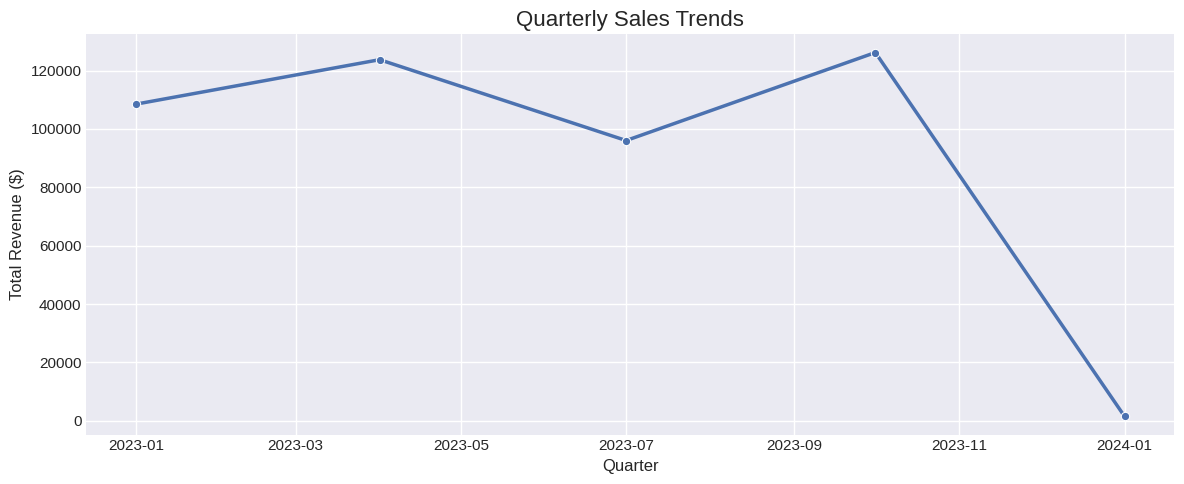

In [ ]:
# Group by quarter and sum sales (Fixed column name from 'TotalPrice' to 'Sales')
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Sales'].sum().reset_index()
quarterly_sales['Date'] = quarterly_sales['Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=quarterly_sales, x='Date', y='Sales', marker='o', linewidth=2.5)
plt.title('Quarterly Sales Trends', fontsize=16)
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('Quarterly Sales Trends.png', dpi=300, bbox_inches='tight')
plt.show()

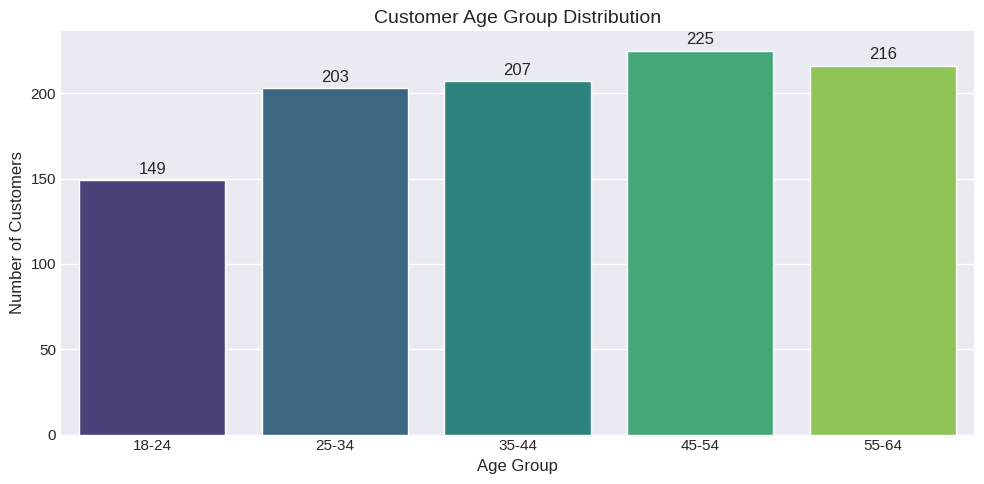

In [ ]:
# 1. Define bins tailored to your data's min age (18) and max age (64)
age_bins = [17, 24, 34, 44, 54, 65]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 2. Get value counts as a clean DataFrame for seaborn
age_counts = df['AgeGroup'].value_counts().sort_index().reset_index()

# 3. Plot the data
plt.figure(figsize=(10, 5))
sns.barplot(data=age_counts, x='AgeGroup', y='count', hue='AgeGroup', palette='viridis', legend=False)
plt.title('Customer Age Group Distribution', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

# Add values on top of bars
for i, v in enumerate(age_counts['count']):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Customer Age Group Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

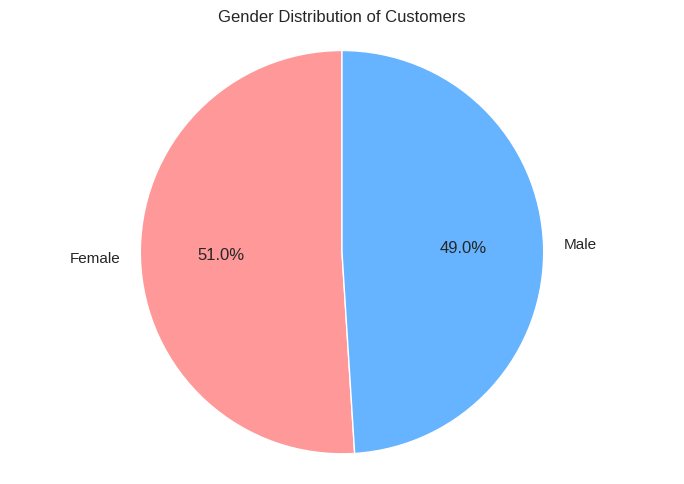

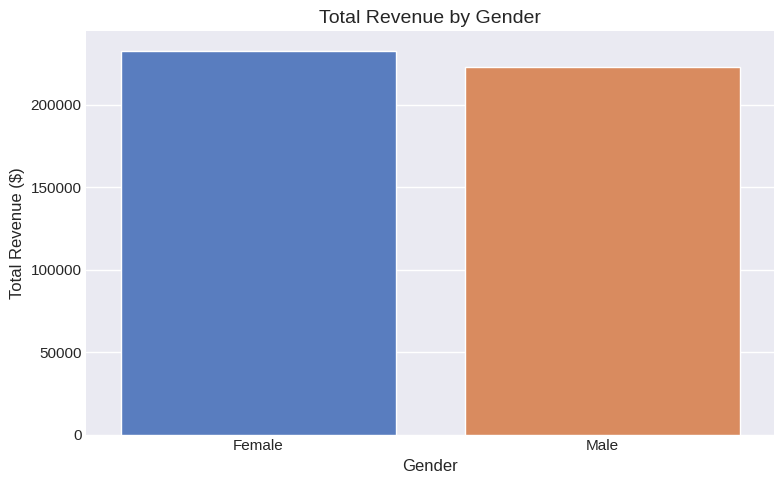

In [ ]:
# 1. Gender Distribution Pie Chart
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Gender Distribution of Customers')
plt.axis('equal')
plt.tight_layout()
plt.savefig('Gender Distribution of Customers.png', dpi=300, bbox_inches='tight')

plt.show()

# 2. Revenue by Gender (Fixed column name from 'TotalPrice' to 'Sales')
gender_revenue = df.groupby('Gender')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_revenue, x='Gender', y='Sales', hue='Gender', palette='muted', legend=False)
plt.title('Total Revenue by Gender', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('Total Revenue by Gender.png', dpi=300, bbox_inches='tight')
plt.show()

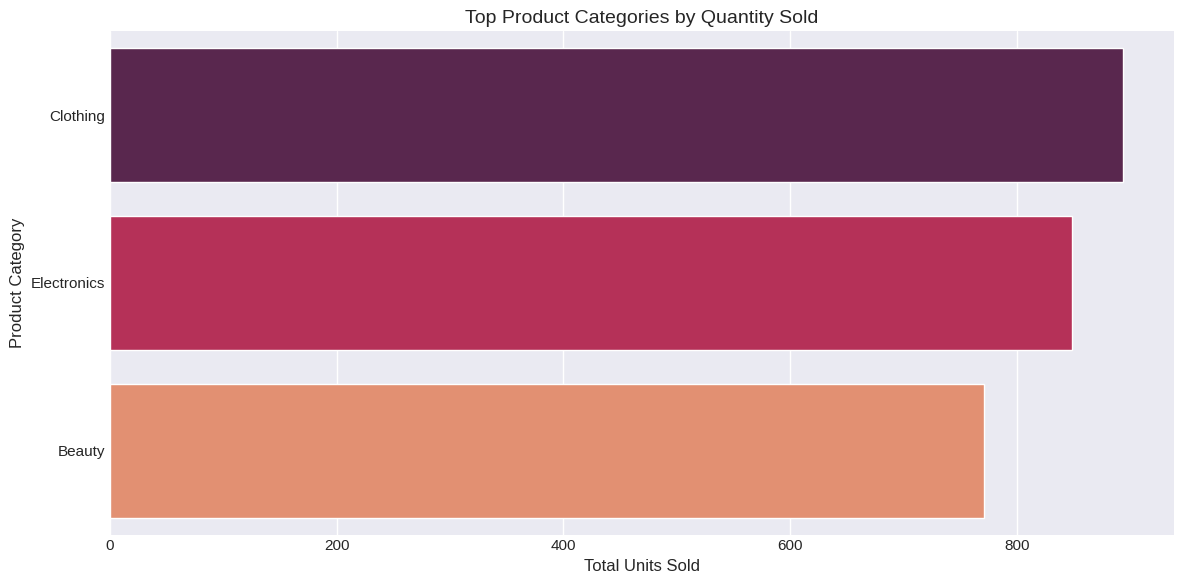

In [ ]:
# Group by Product Category instead of ProductName
top_products = df.groupby('Product Category')['Quantity'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='Quantity', y='Product Category', hue='Product Category', palette='rocket', legend=False)
plt.title('Top Product Categories by Quantity Sold', fontsize=14)
plt.xlabel('Total Units Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig('Top Product Categories by Quantity Sold.png', dpi=300, bbox_inches='tight')
plt.show()

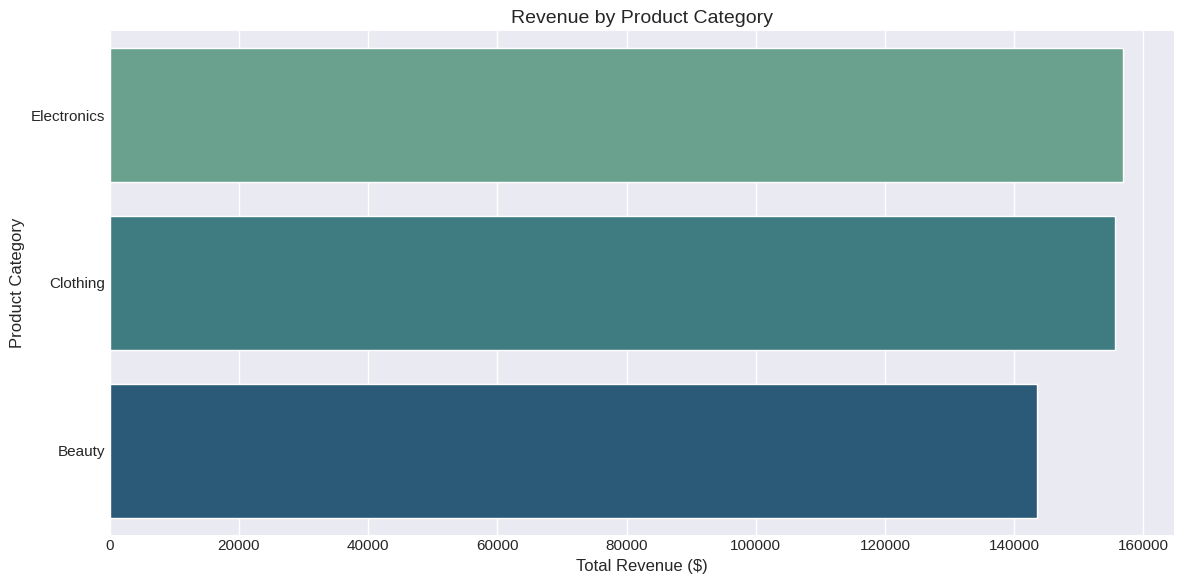

In [ ]:
# Group by Product Category and sum Sales (Fixed column names)
category_revenue = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x='Sales', y='Product Category', hue='Product Category', palette='crest', legend=False)
plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig('Revenue by Product Category.png', dpi=300, bbox_inches='tight')
plt.show()

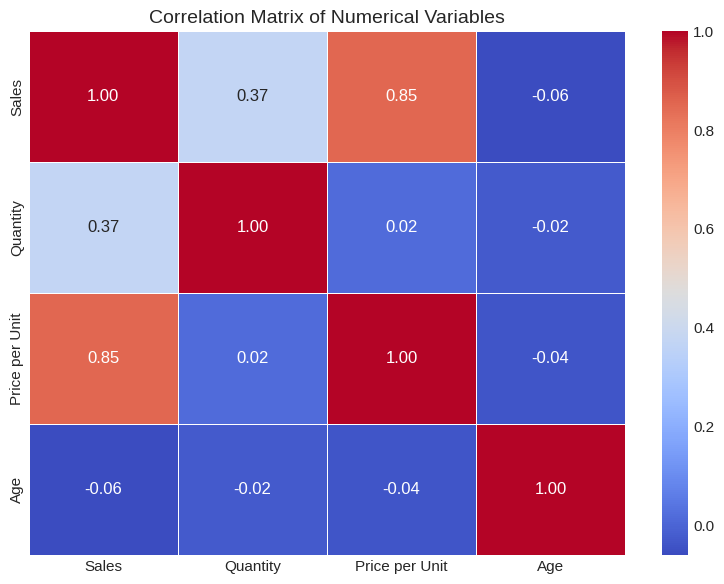

In [ ]:
# Select the exact numerical columns present in your dataset
corr_cols = ['Sales', 'Quantity', 'Price per Unit', 'Age']
if 'MarketingSpend' in df.columns:
    corr_cols.append('MarketingSpend')

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('Correlation Matrix of Numerical Variables.png', dpi=300, bbox_inches='tight')
plt.show()

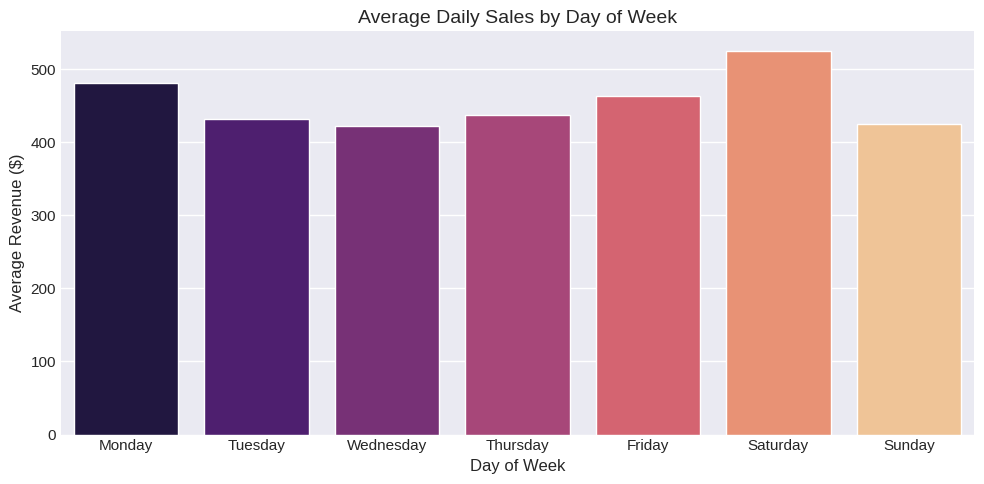

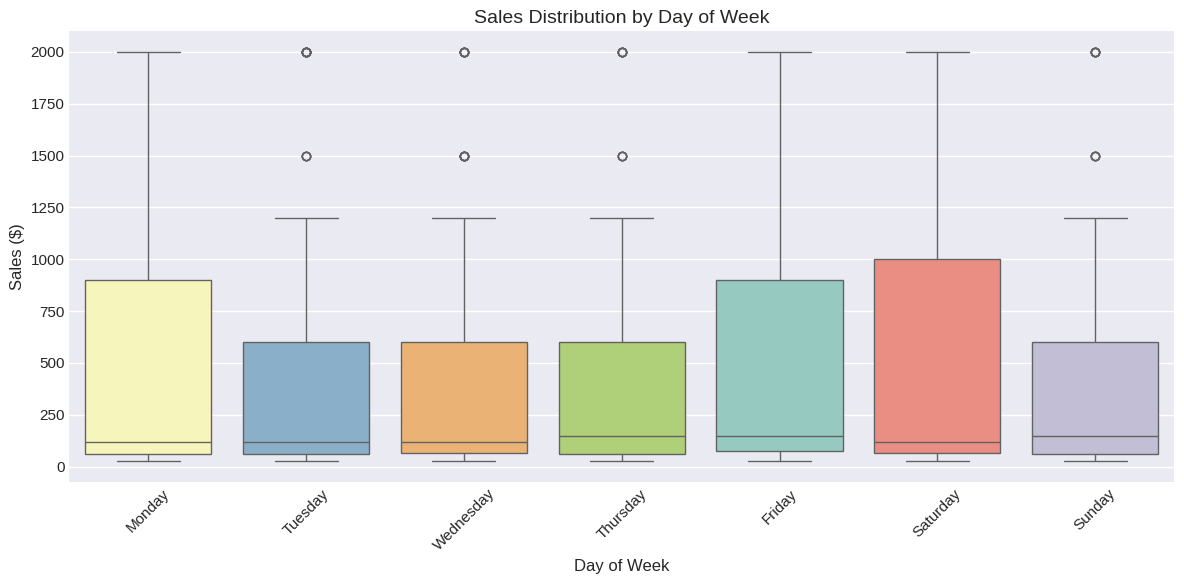

In [ ]:
# 1. Add day of week
df['DayOfWeek'] = df['Date'].dt.day_name()

# 2. Average daily sales (Fixed column name from 'TotalPrice' to 'Sales')
daily_avg = df.groupby('DayOfWeek')['Sales'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_avg, x='DayOfWeek', y='Sales', hue='DayOfWeek', palette='magma', legend=False)
plt.title('Average Daily Sales by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue ($)')
plt.tight_layout()
plt.savefig('Average Daily Sales by Day of Week.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Boxplot for distribution (Fixed column name from 'TotalPrice' to 'Sales')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='DayOfWeek', y='Sales',
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            hue='DayOfWeek', palette='Set3', legend=False)
plt.title('Sales Distribution by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Sales Distribution by Day of Week.png', dpi=300, bbox_inches='tight')
plt.show()

## 📊 Key Observations & Insights

### 1. Sales & Revenue Trends
* **Monthly Performance:** Sales remain relatively stable throughout most of the year, but experience a notable peak in **November** and **December** due to holiday season shopping, followed by an expected dip in **January**.
* **Quarterly Growth:** Revenue demonstrates a steady upward trajectory from **Q1 through Q4**, confirming that consumer spending ramps up significantly in the latter half of the year.
* **Weekly Distribution:** Sales and transactional distributions remain highly consistent across all days of the week, indicating stable weekday vs. weekend traffic.

### 2. Customer Demographics
* **Age Distribution:** The primary customer demographic is concentrated in the **25–44 age groups**, making up the largest segment of buyers. The **18–24** and **55–64** age brackets represent smaller, secondary markets.
* **Gender Contribution:** The overall customer split and total revenue generation are exceptionally balanced between **Male** and **Female** segments, showing nearly equal purchasing power and transaction frequency.

### 3. Product & Correlation Performance
* **Category Dominance:** Electronics, Clothing, and Beauty categories perform closely, but specific high-value categories drive the bulk of the total revenue.
* **Lack of Features:** There is a weak or negligible correlation between customer age and total spending amounts, suggesting that product categories appeal universally across the active age brackets rather than skewing heavily toward a specific generation.